In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('D:\project\dataset\CSV_Files\Train_UWu5bXk.csv')
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        return mis_val_table_ren_columns


In [5]:
missing_values_table(data)

,Missing Values,% of Total Values
Outlet_Size,2410,28.3
Item_Weight,1463,17.2


In [6]:
data['Outlet_Size'].unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Outlet_Size', ylabel='count'>

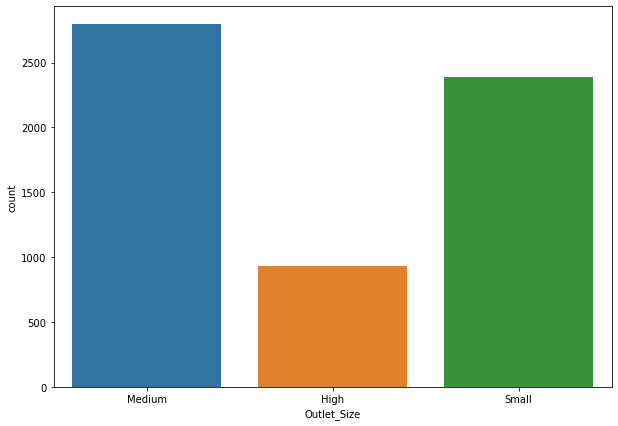

In [7]:
plt.figure(figsize = (10,7))
sns.countplot(data['Outlet_Size'])

In [8]:
data['Outlet_Size'].mode()

0    Medium
dtype: object

In [9]:
data['Outlet_Size']=data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0])

In [10]:
missing_values_table(data)

,Missing Values,% of Total Values
Item_Weight,1463,17.2


C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Item_Weight', ylabel='count'>

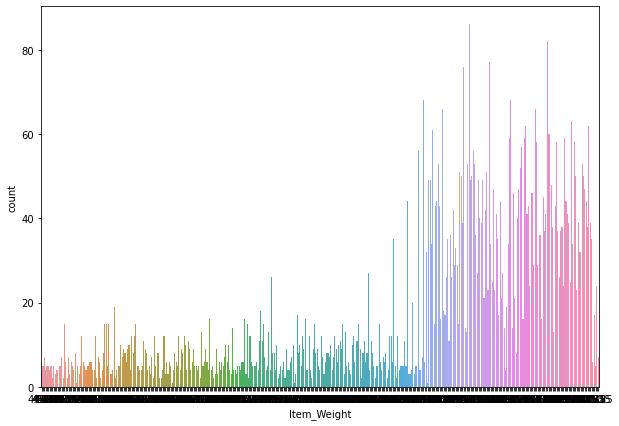

In [11]:
plt.figure(figsize = (10,7))
sns.countplot(data['Item_Weight'])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Item_Weight', ylabel='Density'>

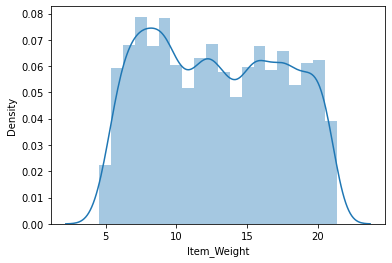

In [12]:
sns.distplot(data['Item_Weight'])

In [13]:
null_perc = data.isnull().sum() / len(data) * 100
column_name = data.columns
new_columns_names = []
for i in range(0, len(null_perc)):
    if null_perc[i] < 20:
        new_columns_names.append(column_name[i])
        
X = data[new_columns_names]
X

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [14]:
X.var().round(3)


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_6692/814397441.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  X.var().round(3)


Item_Weight                       21.562
Item_Visibility                    0.003
Item_MRP                        3878.184
Outlet_Establishment_Year         70.086
Item_Outlet_Sales            2912140.938
dtype: float64

In [15]:
variances = X.var()
column_name = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
new_columns_names = []
for i in range(0, len(variances)):
    if variances[i] > 1:
        new_columns_names.append(column_name[i])
        
new_columns_names

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_6692/533556780.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  variances = X.var()


['Item_Weight', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']

In [16]:
X.skew()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_6692/1164782681.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  X.skew()


Item_Weight                  0.082426
Item_Visibility              1.167091
Item_MRP                     0.127202
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
dtype: float64

In [17]:
skewness = X.skew()
column_name = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
new_columns_names = []
for i in range(0, len(skewness)):
    if skewness[i] < 0.5 and skewness[i] > -0.5:
        new_columns_names.append(column_name[i])
        
new_columns_names

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_6692/162090906.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  skewness = X.skew()


['Item_Weight', 'Item_MRP', 'Outlet_Establishment_Year']

In [18]:
X.kurtosis()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_6692/483527359.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  X.kurtosis()


Item_Weight                 -1.227766
Item_Visibility              1.679445
Item_MRP                    -0.889769
Outlet_Establishment_Year   -1.205694
Item_Outlet_Sales            1.615877
dtype: float64

array([[<AxesSubplot:title={'center':'Item_Weight'}>,
        <AxesSubplot:title={'center':'Item_Visibility'}>],
       [<AxesSubplot:title={'center':'Item_MRP'}>,
        <AxesSubplot:title={'center':'Outlet_Establishment_Year'}>],
       [<AxesSubplot:title={'center':'Item_Outlet_Sales'}>,
        <AxesSubplot:>]], dtype=object)

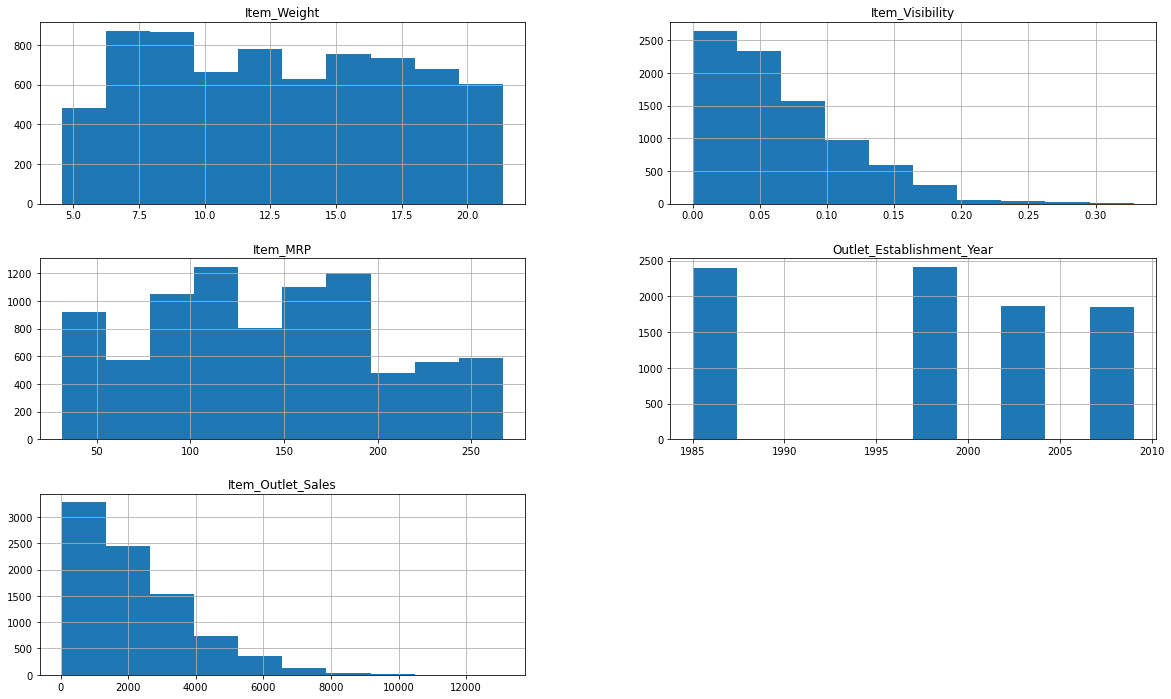

In [19]:
data.hist(figsize=(20, 12))

In [20]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
X = data[['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']]
y = data['Item_Outlet_Sales']

In [22]:
X.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1


In [23]:
X_Scaled = X.copy()
cont_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
scaler = StandardScaler()
X_Scaled = X_Scaled[cont_cols]
X_Scaled = scaler.fit_transform(X_Scaled)
print(X_Scaled)

[[-0.7662174  -0.97073217  1.74745381  0.13954076]
 [-1.49417499 -0.90811123 -1.48902325  1.33410274]
 [ 0.99983356 -0.95691733  0.01004021  0.13954076]
 ...
 [-0.48623371 -0.59978449 -0.89720755  0.73682175]
 [-1.21634502  1.53287976 -0.60797692  1.33410274]
 [ 0.41832897 -0.41193591 -1.05226104 -0.09937163]]


In [24]:
X[cont_cols] = X_Scaled

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


In [25]:
X.head(10)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,-0.766217,Low Fat,-0.970732,Dairy,1.747454,OUT049,0.139541,Medium,Tier 1,Supermarket Type1
1,-1.494175,Regular,-0.908111,Soft Drinks,-1.489023,OUT018,1.334103,Medium,Tier 3,Supermarket Type2
2,0.999834,Low Fat,-0.956917,Meat,0.010040,OUT049,0.139541,Medium,Tier 1,Supermarket Type1
3,1.365966,Regular,-1.281758,Fruits and Vegetables,0.660050,OUT010,0.020085,Medium,Tier 3,Grocery Store
4,-0.845905,Low Fat,-1.281758,Household,-1.399220,OUT013,-1.293934,High,Tier 3,Supermarket Type1
5,-0.530385,Regular,-1.281758,Baking Goods,-1.438734,OUT018,1.334103,Medium,Tier 3,Supermarket Type2
6,0.170651,Regular,-1.034813,Snack Foods,-1.338238,OUT013,-1.293934,High,Tier 3,Supermarket Type1
7,NaN,Low Fat,1.188838,Snack Foods,-0.533641,OUT027,-1.532846,Medium,Tier 3,Supermarket Type3
8,0.719850,Regular,-0.958331,Frozen Foods,-0.706908,OUT045,0.497909,Medium,Tier 2,Supermarket Type1
9,1.365966,Regular,0.548845,Frozen Foods,0.752008,OUT017,1.095190,Medium,Tier 2,Supermarket Type1


In [26]:
cat_cols_indexes = [1, 3, 5, 7, 8, 9]

In [27]:
X['Outlet_Size'].isna()

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool

In [28]:
X['Outlet_Size'].fillna(X['Outlet_Size'].mode()[0], inplace=True)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [29]:
X.isnull().sum()


Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [30]:
data.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [31]:
X = data[['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']]
y = data['Item_Outlet_Sales']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2323)

In [33]:
model = CatBoostRegressor(iterations=198, learning_rate=0.05, depth=8,eval_metric='MAE')

In [34]:
model.fit(X_train, y_train, cat_cols_indexes, eval_set=(X_test, y_test), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1316.1053286	test: 1278.6974269	best: 1278.6974269 (0)	total: 146ms	remaining: 28.7s
1:	learn: 1279.4039523	test: 1242.5911093	best: 1242.5911093 (1)	total: 237ms	remaining: 23.2s
2:	learn: 1244.2814162	test: 1208.0807410	best: 1208.0807410 (2)	total: 323ms	remaining: 21s
3:	learn: 1211.1363276	test: 1176.1448105	best: 1176.1448105 (3)	total: 405ms	remaining: 19.6s
4:	learn: 1180.4099280	test: 1146.0172476	best: 1146.0172476 (4)	total: 496ms	remaining: 19.1s
5:	learn: 1152.0609023	test: 1119.1084461	best: 1119.1084461 (5)	total: 561ms	remaining: 18s
6:	learn: 1124.6845150	test: 1093.4133589	best: 1093.4133589 (6)	total: 641ms	remaining: 17.5s
7:	learn: 1098.9079117	test: 1068.3176749	best: 1068.3176749 (7)	total: 734ms	remaining: 17.4s
8:	learn: 1076.2239172	test: 1046.6640052	best: 1046.6640052 (8)	total: 807ms	remaining: 16.9s
9:	learn: 1054.4448759	test: 1025.8394039	best: 1025.8394039 (9)	total: 881ms	remaining: 16.6s
10:	learn: 1035.0672700	test: 1007.2315898	best: 1007.

91:	learn: 743.3836822	test: 743.8383342	best: 743.7812615 (89)	total: 6.25s	remaining: 7.2s
92:	learn: 742.7718727	test: 743.6066639	best: 743.6066639 (92)	total: 6.31s	remaining: 7.12s
93:	learn: 742.4693572	test: 743.5880663	best: 743.5880663 (93)	total: 6.37s	remaining: 7.05s
94:	learn: 742.2669401	test: 743.5505971	best: 743.5505971 (94)	total: 6.43s	remaining: 6.97s
95:	learn: 742.0385065	test: 743.5076082	best: 743.5076082 (95)	total: 6.5s	remaining: 6.91s
96:	learn: 741.5953243	test: 743.1646459	best: 743.1646459 (96)	total: 6.58s	remaining: 6.85s
97:	learn: 741.2743065	test: 743.1637158	best: 743.1637158 (97)	total: 6.65s	remaining: 6.78s
98:	learn: 741.1102363	test: 743.1732316	best: 743.1637158 (97)	total: 6.71s	remaining: 6.71s
99:	learn: 741.1056559	test: 743.1730805	best: 743.1637158 (97)	total: 6.73s	remaining: 6.6s
100:	learn: 740.8234813	test: 743.1376873	best: 743.1376873 (100)	total: 6.79s	remaining: 6.52s
101:	learn: 740.7326167	test: 743.1190068	best: 743.1190068 (

177:	learn: 723.7855950	test: 741.6431233	best: 741.4737471 (174)	total: 11.5s	remaining: 1.29s
178:	learn: 723.6694475	test: 741.6310186	best: 741.4737471 (174)	total: 11.6s	remaining: 1.23s
179:	learn: 723.4778283	test: 741.6361370	best: 741.4737471 (174)	total: 11.6s	remaining: 1.16s
180:	learn: 723.1090309	test: 741.7423326	best: 741.4737471 (174)	total: 11.7s	remaining: 1.1s
181:	learn: 722.9192968	test: 741.7653105	best: 741.4737471 (174)	total: 11.8s	remaining: 1.03s
182:	learn: 722.7478791	test: 741.8196097	best: 741.4737471 (174)	total: 11.8s	remaining: 969ms
183:	learn: 722.4914827	test: 741.8082435	best: 741.4737471 (174)	total: 11.9s	remaining: 905ms
184:	learn: 722.0775699	test: 741.9822713	best: 741.4737471 (174)	total: 12s	remaining: 840ms
185:	learn: 721.7512469	test: 742.0624649	best: 741.4737471 (174)	total: 12s	remaining: 776ms
186:	learn: 721.4117290	test: 742.1379911	best: 741.4737471 (174)	total: 12.1s	remaining: 711ms
187:	learn: 721.2485085	test: 742.1320691	bes

In [49]:
y.std()

1706.499615733832